In [118]:
### Script to identify the recurrence intervals of all patches in the NSHM, based on all ruptures

import pandas as pd
import geopandas as gpd
from glob import glob
import numpy as np

In [124]:
data_dir = "../data/crustal_solutions"

branches = glob(f"{data_dir}/*/")
sections = gpd.read_file(f"{branches[0]}/ruptures/fault_sections.geojson").set_index('FaultID')
properties = pd.read_csv(f"{branches[0]}/ruptures/properties.csv", index_col=0)
slips = pd.read_csv(f"{branches[0]}/ruptures/average_slips.csv", index_col=0)
n_cols = sections.shape[1]
indices = pd.read_csv(f"{branches[0]}/ruptures/indices.csv", index_col=0)

In [144]:
slips.loc[int(ix)].values[0]

7.213330484457479

In [142]:
slips.loc[int(ix)].values[0] * np.sin(np.radians(sections.loc[rupt_sections]['Rake']))

FaultID
2324    6.778313e+00
2323    6.778313e+00
1190    2.467104e+00
1191    2.467104e+00
1192    2.467104e+00
1193    2.467104e+00
1194    2.467104e+00
1195    2.467104e+00
1196    2.467104e+00
1197    2.467104e+00
1198    2.467104e+00
1199    2.467104e+00
1185    8.833782e-16
1186    8.833782e-16
1187    8.833782e-16
1188    8.833782e-16
1189    8.833782e-16
2043   -2.467104e+00
2044   -2.467104e+00
2045   -2.467104e+00
2046   -2.467104e+00
2047   -2.467104e+00
2048   -2.467104e+00
2074   -2.467104e+00
2075   -2.467104e+00
2076   -2.467104e+00
2077   -2.467104e+00
2078   -2.467104e+00
2079   -2.467104e+00
2080   -2.467104e+00
2081   -2.467104e+00
1424   -6.778313e+00
1425   -6.778313e+00
1426   -6.778313e+00
1427   -6.778313e+00
1914   -7.213330e+00
1913   -7.213330e+00
1916   -7.213330e+00
1915   -7.213330e+00
1477   -7.213330e+00
1476   -7.213330e+00
1478   -7.213330e+00
1479   -7.213330e+00
Name: Rake, dtype: float64

In [146]:
sections.loc[rupt_sections]

,FaultName,DipDeg,Rake,LowDepth,UpDepth,DipDir,AseismicSlipFactor,CouplingCoeff,SlipRate,ParentID,ParentName,SlipRateStdDev,geometry
FaultID,,,,,,,,,,,,,
2324,"Woodville, Subsection 1",70.0,110.0,21.9200,0.0,316.2,0.0,1.0,0.2,556,Woodville,0.10,"LINESTRING (175.94849 -40.29581, 175.99380 -40..."
2323,"Woodville, Subsection 0",70.0,110.0,21.9200,0.0,316.2,0.0,1.0,0.2,556,Woodville,0.10,"LINESTRING (175.85790 -40.35860, 175.87780 -40..."
1190,"Mohaka: South, Subsection 0",80.0,160.0,22.2400,0.0,301.5,0.0,1.0,4.0,269,Mohaka: South,1.00,"LINESTRING (175.79420 -40.36710, 175.82700 -40..."
1191,"Mohaka: South, Subsection 1",80.0,160.0,22.2400,0.0,301.5,0.0,1.0,4.0,269,Mohaka: South,1.00,"LINESTRING (175.87215 -40.28753, 175.89110 -40..."
1192,"Mohaka: South, Subsection 2",80.0,160.0,22.2400,0.0,301.5,0.0,1.0,4.0,269,Mohaka: South,1.00,"LINESTRING (175.95287 -40.20994, 175.96010 -40..."
1193,"Mohaka: South, Subsection 3",80.0,160.0,22.2400,0.0,301.5,0.0,1.0,4.0,269,Mohaka: South,1.00,"LINESTRING (176.01779 -40.12409, 176.06030 -40..."
1194,"Mohaka: South, Subsection 4",80.0,160.0,22.2400,0.0,301.5,0.0,1.0,4.0,269,Mohaka: South,1.00,"LINESTRING (176.08258 -40.03801, 176.09750 -40..."
1195,"Mohaka: South, Subsection 5",80.0,160.0,22.2400,0.0,301.5,0.0,1.0,4.0,269,Mohaka: South,1.00,"LINESTRING (176.14997 -39.95315, 176.15500 -39..."
1196,"Mohaka: South, Subsection 6",80.0,160.0,22.2400,0.0,301.5,0.0,1.0,4.0,269,Mohaka: South,1.00,"LINESTRING (176.21157 -39.86574, 176.25570 -39..."


In [143]:
sections.loc[rupt_sections]['Rake']

FaultID
2324    110.0
2323    110.0
1190    160.0
1191    160.0
1192    160.0
1193    160.0
1194    160.0
1195    160.0
1196    160.0
1197    160.0
1198    160.0
1199    160.0
1185    180.0
1186    180.0
1187    180.0
1188    180.0
1189    180.0
2043   -160.0
2044   -160.0
2045   -160.0
2046   -160.0
2047   -160.0
2048   -160.0
2074   -160.0
2075   -160.0
2076   -160.0
2077   -160.0
2078   -160.0
2079   -160.0
2080   -160.0
2081   -160.0
1424   -110.0
1425   -110.0
1426   -110.0
1427   -110.0
1914    -90.0
1913    -90.0
1916    -90.0
1915    -90.0
1477    -90.0
1476    -90.0
1478    -90.0
1479    -90.0
Name: Rake, dtype: float64

In [ ]:
for branch in branches:
    print(branch)
    rates = pd.read_csv(f"{branch}/solution/rates.csv")
    rates = rates[rates["Annual Rate"] > 0]
    sections[branch[-5:-1]] = 0.
    for _, (ix, rate) in rates.iterrows():
        rupt_sections = indices.loc[int(ix)][1:indices.loc[int(ix), 'Num Sections'] + 1].values
        dip_slip = slips.loc[int(ix)] * np.sin(np.radians(int(ix)))
        if dip_slip
        sections.loc[rupt_sections, branch[-5:-1]] += rate

sections['TotalRI'] = sections.iloc[:, n_cols:].sum(axis=1)
sections['MaxBranchRI'] = sections.iloc[:, n_cols:-1].max(axis=1)
sections['MedBranchRI'] = np.median(sections.iloc[:, n_cols:-2], axis=1)

sections['MedBranchRI_1e-6'] = np.where(sections['MedBranchRI'] < 1e-6, 0, sections['MedBranchRI'])

sections.iloc[:, n_cols:]

../data/crustal_solutions\NZSHM22_InversionSolution-QXV0b21hdGlvblRhc2s6MTA3MDA2\
../data/crustal_solutions\NZSHM22_InversionSolution-QXV0b21hdGlvblRhc2s6MTA3MDE1\
../data/crustal_solutions\NZSHM22_InversionSolution-QXV0b21hdGlvblRhc2s6MTA3MDE2\
../data/crustal_solutions\NZSHM22_InversionSolution-QXV0b21hdGlvblRhc2s6MTA3MDE5\
../data/crustal_solutions\NZSHM22_InversionSolution-QXV0b21hdGlvblRhc2s6MTA3MDEz\
../data/crustal_solutions\NZSHM22_InversionSolution-QXV0b21hdGlvblRhc2s6MTA3MDI0\
../data/crustal_solutions\NZSHM22_TimeDependentInversionSolution-QXV0b21hdGlvblRhc2s6MTExNjE5\
../data/crustal_solutions\NZSHM22_TimeDependentInversionSolution-QXV0b21hdGlvblRhc2s6MTExNjI2\
../data/crustal_solutions\NZSHM22_TimeDependentInversionSolution-QXV0b21hdGlvblRhc2s6MTExNjI3\
../data/crustal_solutions\NZSHM22_TimeDependentInversionSolution-QXV0b21hdGlvblRhc2s6MTExNjI5\
../data/crustal_solutions\NZSHM22_TimeDependentInversionSolution-QXV0b21hdGlvblRhc2s6MTExNjM3\
../data/crustal_solutions\NZSHM22

,MDA2,MDE1,MDE2,MDE5,MDEz,MDI0,NjE5,NjI2,NjI3,NjI5,NjM3,NjMy,TotalRI,MaxBranchRI,MedBranchRI,MedBranchRI_1e-6
FaultID,,,,,,,,,,,,,,,,
0,0.000000,0.000050,0.000000,0.000016,0.000018,0.000000,0.000000,0.000018,0.000050,0.000000,0.000000,0.000016,0.000167,0.000050,0.000008,0.000008
1,0.000000,0.000050,0.000000,0.000016,0.000018,0.000000,0.000000,0.000018,0.000050,0.000000,0.000000,0.000016,0.000167,0.000050,0.000008,0.000008
2,0.000000,0.000041,0.000000,0.000000,0.000012,0.000000,0.000000,0.000012,0.000042,0.000000,0.000000,0.000000,0.000106,0.000042,0.000000,0.000000
3,0.000005,0.000005,0.000092,0.000076,0.000004,0.000095,0.000005,0.000005,0.000005,0.000095,0.000098,0.000079,0.000563,0.000098,0.000041,0.000041
4,0.000005,0.000005,0.000092,0.000076,0.000004,0.000095,0.000005,0.000005,0.000005,0.000095,0.000098,0.000079,0.000563,0.000098,0.000041,0.000041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2320,0.000031,0.000034,0.000000,0.000074,0.000033,0.000031,0.000024,0.000026,0.000027,0.000000,0.000016,0.000061,0.000358,0.000074,0.000029,0.000029
2321,0.000053,0.000056,0.000013,0.000083,0.000055,0.000036,0.000043,0.000045,0.000046,0.000013,0.000022,0.000066,0.000528,0.000083,0.000045,0.000045
2322,0.000053,0.000056,0.000013,0.000083,0.000055,0.000036,0.000043,0.000045,0.000046,0.000013,0.000022,0.000066,0.000528,0.000083,0.000045,0.000045


In [121]:
sections.to_file(f"{data_dir}/fault_sections_ri.geojson", driver='GeoJSON')

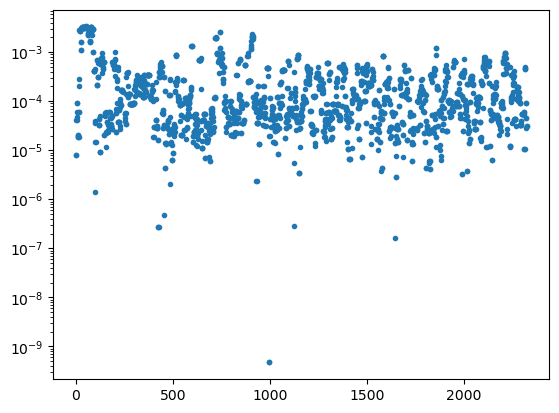

In [122]:
import matplotlib.pyplot as plt
plt.plot(sections.index, sections.MedBranchRI, '.')
plt.yscale('log')